In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

**Loading Data**

In [ ]:
data = pd.read_csv("SYNTHETIC_EV_DATA.csv")

print(data.head())

   connectionTime_decimal  chargingDuration  kWhDelivered  dayIndicator
0               15.332910          2.301191     11.469551             1
1               16.811495          4.941774      3.611695             1
2               21.151696          3.567173     14.455706             1
3               14.988554          3.089371      5.985330             1
4               15.078276          0.145047      1.274458             1


**Correcting Null values**

In [ ]:
print(data.isnull().sum())

connectionTime_decimal    0
chargingDuration          0
kWhDelivered              0
dayIndicator              0
dtype: int64


In [ ]:
data = data.dropna()

**Splitting dataset**

In [ ]:
client1 = data.iloc[:len(data)//2]
client2 = data.iloc[len(data)//2:]

print("Client1 size:", client1.shape)
print("Client2 size:", client2.shape)

Client1 size: (982619, 4)
Client2 size: (982620, 4)


In [ ]:
X1 = client1[["connectionTime_decimal","chargingDuration","dayIndicator"]]
y1 = client1["kWhDelivered"]

X2 = client2[["connectionTime_decimal","chargingDuration","dayIndicator"]]
y2 = client2["kWhDelivered"]

model1.fit(X1, y1)
model2.fit(X2, y2)

LinearRegression()

In [ ]:
coef_avg = (model1.coef_ + model2.coef_) / 2
intercept_avg = (model1.intercept_ + model2.intercept_) / 2

print("Federated coefficients:", coef_avg)

Federated coefficients: [ 1.63344352e-01  7.58900685e-01 -1.14260263e-06]


In [ ]:
global_model = LinearRegression()

global_model.coef_ = coef_avg
global_model.intercept_ = intercept_avg

In [ ]:
pred1 = model1.predict(X)

mse1 = mean_squared_error(y, pred1)
rmse1 = np.sqrt(mse1)

print("Client1 RMSE:", rmse1)

Client1 RMSE: 4.8445226258440535


In [ ]:
pred2 = model2.predict(X)

mse2 = mean_squared_error(y, pred2)
rmse2 = np.sqrt(mse2)

print("Client2 RMSE:", rmse2)

Client2 RMSE: 4.844518782690881


In [ ]:
pred_fed = global_model.predict(X)

mse_fed = mean_squared_error(y, pred_fed)
rmse = np.sqrt(mse_fed)

r2 = r2_score(y, pred_fed)

print("Federated RMSE:", rmse)
print("Federated R2 Score:", r2)

Federated RMSE: 4.844518866806915
Federated R2 Score: 0.2778103130412506


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
print(type(X1))
print(type(X))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


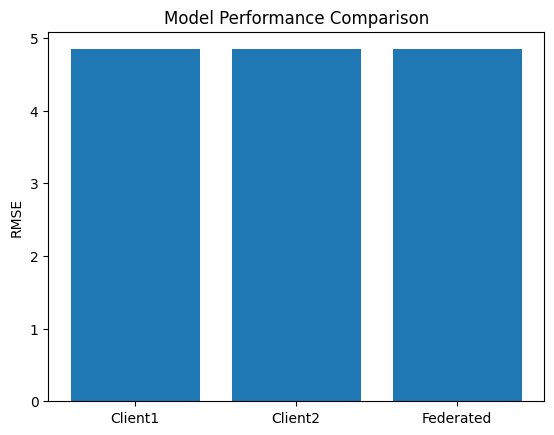

In [ ]:
models = ["Client1","Client2","Federated"]
rmse_values = [rmse1, rmse2, rmse]

plt.bar(models, rmse_values)
plt.title("Model Performance Comparison")
plt.ylabel("RMSE")
plt.show()